In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score
import streamlit as st

In [6]:
df = pd.read_csv("datasets/DP_LMS_AI_Internship_Assessment_Dataset.csv")

2026-10-03 20:42:33.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 20:42:33.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

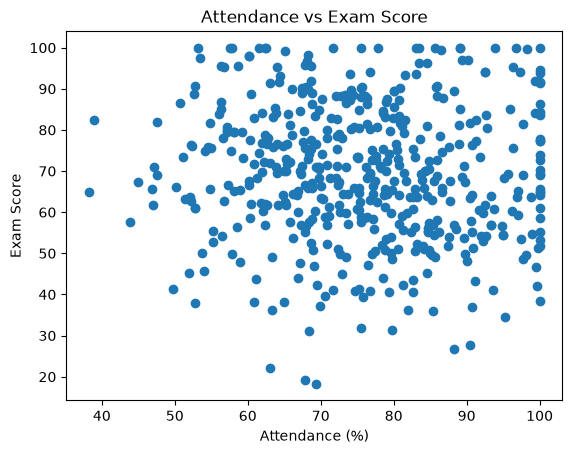

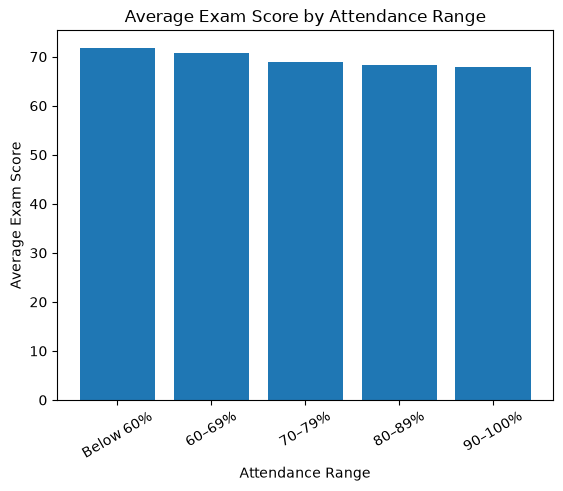

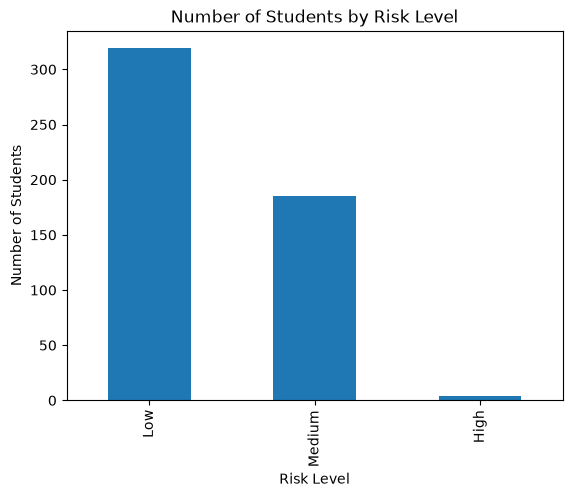

In [8]:


# Page title
st.title("Student Performance Dashboard")

st.write("Overview of student attendance, academic performance, and risk levels.")

# -----------------------------
# 1. Summary Statistics
# -----------------------------

total_students = len(df)
average_attendance = df["attendance_pct"].mean()
average_exam_score = df["exam_score"].mean()
average_course_completion = df["course_completion_pct"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Students", total_students)
col2.metric("Average Attendance", f"{average_attendance:.2f}%")
col3.metric("Average Exam Score", f"{average_exam_score:.2f}")
col4.metric("Average Course Completion", f"{average_course_completion:.2f}%")

# -----------------------------
# 2. Risk Level
# -----------------------------

st.subheader("Student Risk Levels")

risk_count = df["risk_level"].value_counts()

col1, col2, col3 = st.columns(3)

col1.metric("Low Risk", risk_count.get("Low", 0))
col2.metric("Medium Risk", risk_count.get("Medium", 0))
col3.metric("High Risk", risk_count.get("High", 0))

# -----------------------------
# 3. Chart 1
# Attendance vs Exam Score
# -----------------------------

st.subheader("Attendance vs Exam Score")

fig, ax = plt.subplots()

ax.scatter(
    df["attendance_pct"],
    df["exam_score"]
)

ax.set_xlabel("Attendance (%)")
ax.set_ylabel("Exam Score")
ax.set_title("Attendance vs Exam Score")

st.pyplot(fig)

# -----------------------------
# 4. Chart 2
# Average Exam Score by Attendance Range
# -----------------------------

st.subheader("Average Exam Score by Attendance Range")

df["attendance_range"] = pd.cut(
    df["attendance_pct"],
    bins=[0, 60, 70, 80, 90, 100],
    labels=[
        "Below 60%",
        "60–69%",
        "70–79%",
        "80–89%",
        "90–100%"
    ]
)

avg_exam = df.groupby(
    "attendance_range",
    observed=True
)["exam_score"].mean()

fig, ax = plt.subplots()

ax.bar(avg_exam.index, avg_exam.values)

ax.set_xlabel("Attendance Range")
ax.set_ylabel("Average Exam Score")
ax.set_title("Average Exam Score by Attendance Range")

plt.xticks(rotation=30)

st.pyplot(fig)

# -----------------------------
# 5. Chart 3
# Risk Level Distribution
# -----------------------------

st.subheader("Student Risk Distribution")

fig, ax = plt.subplots()

risk_count.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Risk Level")
ax.set_ylabel("Number of Students")
ax.set_title("Number of Students by Risk Level")

st.pyplot(fig)